# 8. UTS 2

# 2. Lakukan analisa clutering dokumen pada data email berikut

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import re
import nltk

In [2]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")
print(df.head())
print(df.columns)

   id                                               Text Unnamed: 2  \
0   1  Go until jurong point, crazy.. Available only ...        NaN   
1   2                      Ok lar... Joking wif u oni...        NaN   
2   3  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   4  U dun say so early hor... U c already then say...        NaN   
4   5  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Index(['id', 'Text', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [6]:
df = df[['Text']].dropna()
df = df.rename(columns={'Text': 'text'})

Preprocessing

In [7]:
def clean_text(text):
    text = str(text).lower()                               # ubah ke huruf kecil
    text = re.sub(r'[^a-z\s]', '', text)                   # hapus karakter non-huruf
    text = " ".join([word for word in text.split()
                     if word not in stopwords.words('english')])  # hapus stopwords
    return text

df['clean_text'] = df['text'].apply(clean_text)

TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])

In [9]:
k = 2  #ingin 2 cluster (spam dan non-spam)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

In [10]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X.toarray())

tujuan dari PCA(Peincipal Component Analysis) adalah mengubah data berdimensi tinggi menjadi beberapa komponen utama.

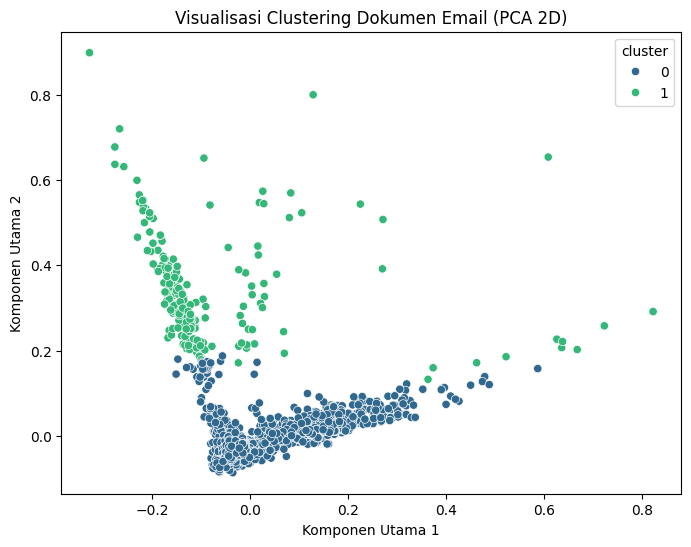

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=df['cluster'], palette='viridis')
plt.title("Visualisasi Clustering Dokumen Email (PCA 2D)")
plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.show()

analisis hasil cluster

In [12]:
for i in range(k):
    print(f"\n🟢 Cluster {i}:")
    sample_texts = df[df['cluster'] == i]['text'].sample(5, random_state=42)
    for txt in sample_texts:
        print("-", txt[:100], "...")


🟢 Cluster 0:
- \HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAROUND! HOWDY GORGEOUS ...
- Correct. So how was work today ...
- Yes.i'm in office da:) ...
- Sorry that was my uncle. I.ll keep in touch ...
- Just sing HU. I think its also important to find someone female that know the place well preferably  ...

🟢 Cluster 1:
- Finish already... Yar they keep saying i mushy... I so embarrassed ok... ...
- Ok... ...
- Ok then i come n pick u at engin? ...
- Hi, wkend ok but journey terrible. Wk not good as have huge back log of marking to do ...
- Ok... Then r we meeting later? ...


menampilkan kata yang paling penting di cluster 0 dan 1

In [14]:
print("\n🔤 Top terms per cluster:")
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    print(f"\nCluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))


🔤 Top terms per cluster:

Cluster 0:
im, call, get, ur, ltgt, dont, know, come, got, like

Cluster 1:
ok, ill, later, sorry, call, lor, meeting, go, thanx, come
